In [ ]:
import sys
import pandas as pd
import numpy as np

print("Python path:")
print(sys.executable)

print("\nFraudShield notebook is ready!")

Python path:
c:\ml\fraudshield\.venv\Scripts\python.exe

FraudShield notebook is ready!


In [ ]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/PS_20174392719_1491204439457_log.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Count normal and fraudulent transactions
fraud_counts = df["isFraud"].value_counts()

print("Transaction Counts:")
print(fraud_counts)

print("\nFraud Percentage:")
print(
    (df["isFraud"].value_counts(normalize=True) * 100).round(4)
)

Transaction Counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


In [ ]:
# Dataset overview

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(6362620, 11)

Column Names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: 

In [ ]:
columns_to_check = ["type", "nameOrig", "nameDest", "isFlaggedFraud"]

for column in columns_to_check:
    print(f"\n{'=' * 50}")
    print(f"Column: {column}")
    print(f"Unique values: {df[column].nunique()}")
    print(df[column].value_counts().head(10))


Column: type
Unique values: 5
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Column: nameOrig
Unique values: 6353307
nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

Column: nameDest
Unique values: 2722362
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

Column: isFlaggedFraud
Unique values: 2
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [ ]:
# Fraud analysis by transaction type

fraud_by_type = (
    df.groupby("type")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_by_type["fraud_rate"] = (
    fraud_by_type["fraud_rate"] * 100
).round(4)

fraud_by_type = fraud_by_type.sort_values(
    by="fraud_rate",
    ascending=False
)

fraud_by_type

,total_transactions,fraud_transactions,fraud_rate
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


In [ ]:
# Investigate the relationship between isFlaggedFraud and isFraud

flag_fraud_table = pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"],
    margins=True
)

flag_fraud_table

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [ ]:
# Look directly at transactions flagged as fraud

flagged_transactions = df[df["isFlaggedFraud"] == 1]

print("Number of flagged transactions:")
print(len(flagged_transactions))

print("\nFraud distribution among flagged transactions:")
print(flagged_transactions["isFraud"].value_counts())

flagged_transactions.head()

Number of flagged transactions:
16

Fraud distribution among flagged transactions:
isFraud
1    16
Name: count, dtype: int64


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.0,0.0,1,1


In [ ]:
# Compare transaction amount statistics

amount_comparison = (
    df.groupby("isFraud")["amount"]
    .describe()
)

amount_comparison

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [ ]:
# More useful percentile comparison

amount_percentiles = df.groupby("isFraud")["amount"].quantile(
    [0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

amount_percentiles

isFraud      
0        0.01    4.492400e+02
         0.25    1.336840e+04
         0.50    7.468472e+04
         0.75    2.083648e+05
         0.90    3.643734e+05
         0.95    5.156104e+05
         0.99    1.586064e+06
1        0.01    1.842000e+03
         0.25    1.270913e+05
         0.50    4.414234e+05
         0.75    1.517771e+06
         0.90    4.521724e+06
         0.95    8.006429e+06
         0.99    1.000000e+07
Name: amount, dtype: float64

In [ ]:
# Compare transaction amounts by transaction type and fraud status

amount_by_type = (
    df.groupby(["type", "isFraud"])["amount"]
    .describe()
)

amount_by_type

count          mean           std    min          25%  \
type     isFraud                                                              
CASH_IN  0        1399284.0  1.689202e+05  1.265083e+05   0.04   70510.1825   
CASH_OUT 0        2233384.0  1.739172e+05  1.312222e+05   0.01   72627.6900   
         1           4116.0  1.455103e+06  2.393842e+06   0.00  125464.4500   
DEBIT    0          41432.0  5.483665e+03  1.331854e+04   0.55    1500.1800   
PAYMENT  0        2151495.0  1.305760e+04  1.255645e+04   0.02    4383.8200   
TRANSFER 0         528812.0  9.062290e+05  1.874155e+06   2.60  216570.7650   
         1           4097.0  1.480892e+06  2.414890e+06  63.80  128417.9600   

                         50%           75%          max  
type     isFraud                                         
CASH_IN  0        143427.710  2.398991e+05   1915267.90  
CASH_OUT 0        146946.560  2.461812e+05   2847566.62  
         1        435516.905  1.500761e+06  10000000.00  
DEBIT    0          3048.990  5.479175e+03    569077.51  
PAYMENT  0          9482.190  1.756122e+04    238637.98  
TRANSFER 0        486521.910  9.727336e+05  92445516.64  
         1        445705.760  1.534985e+06  10000000.00

In [ ]:
# Calculate expected and actual sender balance changes

sender_balance_analysis = df.copy()

sender_balance_analysis["expected_newbalanceOrig"] = (
    sender_balance_analysis["oldbalanceOrg"]
    - sender_balance_analysis["amount"]
)

sender_balance_analysis["sender_balance_error"] = (
    sender_balance_analysis["expected_newbalanceOrig"]
    - sender_balance_analysis["newbalanceOrig"]
)

# Compare balance error for normal and fraudulent transactions

sender_error_summary = (
    sender_balance_analysis
    .groupby("isFraud")["sender_balance_error"]
    .describe()
)

sender_error_summary

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-201338.558109,606928.890826,-92445516.64,-249953.43,-69049.31,-3034.305,1.000000e-02
1,8213.0,-10692.325265,265146.131130,-10000000.00,0.00,0.00,0.000,3.725290e-09


In [ ]:
# Focus on transaction types where fraud occurs
fraud_related_df = df[
    df["type"].isin(["TRANSFER", "CASH_OUT"])
].copy()

# Calculate actual sender balance change
fraud_related_df["sender_balance_change"] = (
    fraud_related_df["oldbalanceOrg"]
    - fraud_related_df["newbalanceOrig"]
)

# Difference between transaction amount and sender balance change
fraud_related_df["sender_amount_difference"] = (
    fraud_related_df["amount"]
    - fraud_related_df["sender_balance_change"]
)

# Compare the difference for normal vs fraud transactions
sender_difference_summary = (
    fraud_related_df
    .groupby("isFraud")["sender_amount_difference"]
    .describe()
)

sender_difference_summary

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,2762196.0,286803.509954,876375.192156,-1.000000e-02,52613.43,144200.825,280466.255,92445516.64
1,8213.0,10692.325265,265146.131130,-3.725290e-09,0.00,0.000,0.000,10000000.00


In [ ]:
# Check whether sender balance change matches transaction amount

fraud_related_df["sender_balance_matches"] = (
    fraud_related_df["sender_amount_difference"].abs() < 0.01
).astype(int)

balance_match_summary = pd.crosstab(
    fraud_related_df["sender_balance_matches"],
    fraud_related_df["isFraud"],
    normalize="columns"
) * 100

balance_match_summary.round(2)

isFraud,0,1
sender_balance_matches,,
0,90.47,0.55
1,9.53,99.45


In [ ]:
# Calculate receiver balance change

fraud_related_df["receiver_balance_change"] = (
    fraud_related_df["newbalanceDest"]
    - fraud_related_df["oldbalanceDest"]
)

# Compare transaction amount with receiver balance change

fraud_related_df["receiver_amount_difference"] = (
    fraud_related_df["amount"]
    - fraud_related_df["receiver_balance_change"]
)

# Create a feature indicating whether they match

fraud_related_df["receiver_balance_matches"] = (
    fraud_related_df["receiver_amount_difference"].abs() < 0.01
).astype(int)

# Compare normal and fraudulent transactions

receiver_match_summary = pd.crosstab(
    fraud_related_df["receiver_balance_matches"],
    fraud_related_df["isFraud"],
    normalize="columns"
) * 100

receiver_match_summary.round(2)

isFraud,0,1
receiver_balance_matches,,
0,20.22,56.23
1,79.78,43.77


In [ ]:
balance_columns = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

for column in balance_columns:
    print(f"\n{'=' * 50}")
    print(f"Column: {column}")

    zero_percentage = (
        df[column].eq(0)
        .groupby(df["isFraud"])
        .mean() * 100
    )

    print(zero_percentage.round(2))


Column: oldbalanceOrg
isFraud
0    33.09
1     0.50
Name: oldbalanceOrg, dtype: float64

Column: newbalanceOrig
isFraud
0    56.68
1    98.05
Name: newbalanceOrig, dtype: float64

Column: oldbalanceDest
isFraud
0    42.48
1    65.15
Name: oldbalanceDest, dtype: float64

Column: newbalanceDest
isFraud
0    38.33
1    49.81
Name: newbalanceDest, dtype: float64


In [ ]:
# Compare time step distribution for normal and fraudulent transactions

step_summary = (
    df.groupby("isFraud")["step"]
    .describe()
)

step_summary

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,243.235663,142.140194,1.0,156.0,239.0,334.0,718.0
1,8213.0,368.413856,216.388690,1.0,181.0,367.0,558.0,743.0


In [ ]:
# Number of fraud transactions across time steps

fraud_by_step = (
    df[df["isFraud"] == 1]
    .groupby("step")
    .size()
    .sort_values(ascending=False)
)

print("Number of time steps containing fraud:", fraud_by_step.shape[0])

print("\nTop 10 steps with the highest number of fraud transactions:")
print(fraud_by_step.head(10))

Number of time steps containing fraud: 741

Top 10 steps with the highest number of fraud transactions:
step
212    40
523    30
501    28
387    28
249    28
425    28
730    28
160    26
398    26
694    24
dtype: int64


In [ ]:
# Calculate fraud rate for each time step

step_analysis = (
    df.groupby("step")
    .agg(
        total_transactions=("isFraud", "count"),
        fraud_transactions=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    )
)

# Convert fraud rate to percentage
step_analysis["fraud_rate"] = step_analysis["fraud_rate"] * 100

print("Top 10 steps with the highest fraud rate:\n")

display(
    step_analysis
    .sort_values("fraud_rate", ascending=False)
    .head(10)
)

Top 10 steps with the highest fraud rate:



,total_transactions,fraud_transactions,fraud_rate
step,,,
727,12,12,100.0
743,8,8,100.0
742,14,14,100.0
410,20,20,100.0
411,16,16,100.0
412,8,8,100.0
414,16,16,100.0
415,16,16,100.0
417,6,6,100.0


In [ ]:
# Check how often accounts appear in the dataset

orig_account_counts = df["nameOrig"].value_counts()
dest_account_counts = df["nameDest"].value_counts()

print("ORIGIN ACCOUNTS")
print("-" * 40)
print("Unique origin accounts:", df["nameOrig"].nunique())
print("Total transactions:", len(df))
print("Maximum transactions from one origin account:", orig_account_counts.max())

print("\nDESTINATION ACCOUNTS")
print("-" * 40)
print("Unique destination accounts:", df["nameDest"].nunique())
print("Total transactions:", len(df))
print("Maximum transactions received by one destination account:", dest_account_counts.max())

print("\nTop 10 most frequent destination accounts:")
print(dest_account_counts.head(10))

ORIGIN ACCOUNTS
----------------------------------------
Unique origin accounts: 6353307
Total transactions: 6362620
Maximum transactions from one origin account: 3

DESTINATION ACCOUNTS
----------------------------------------
Unique destination accounts: 2722362
Total transactions: 6362620
Maximum transactions received by one destination account: 113

Top 10 most frequent destination accounts:
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64


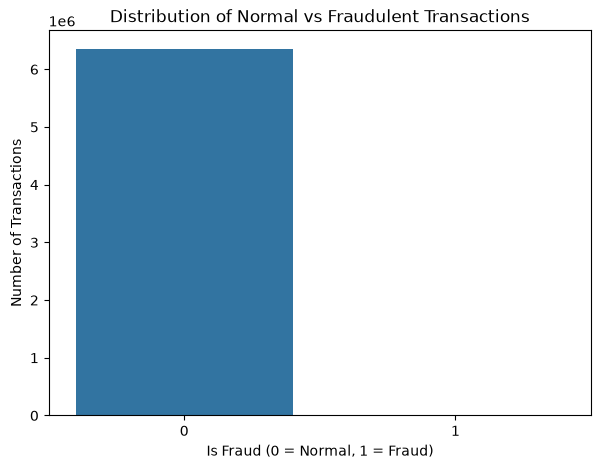

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Distribution of Normal vs Fraudulent Transactions")
plt.xlabel("Is Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


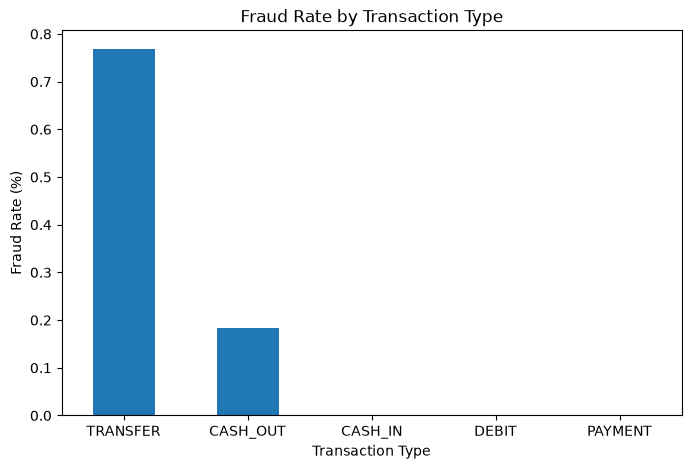

In [ ]:
# Calculate fraud rate for each transaction type

fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(fraud_rate_by_type)

plt.figure(figsize=(8, 5))

fraud_rate_by_type.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)

plt.show()

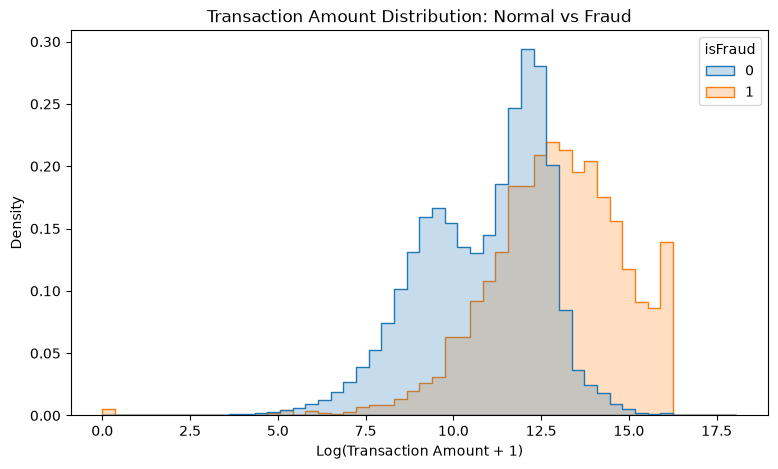

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample normal transactions for visualization
normal_sample = df[df["isFraud"] == 0].sample(
    n=100000,
    random_state=42
)

# Keep all fraud transactions because there are relatively few
fraud_sample = df[df["isFraud"] == 1]

# Combine them for plotting
plot_df = pd.concat([normal_sample, fraud_sample])

# Create log-transformed amount for visualization
plot_df = plot_df.copy()
plot_df["log_amount"] = np.log1p(plot_df["amount"])

plt.figure(figsize=(9, 5))

sns.histplot(
    data=plot_df,
    x="log_amount",
    hue="isFraud",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Transaction Amount Distribution: Normal vs Fraud")
plt.xlabel("Log(Transaction Amount + 1)")
plt.ylabel("Density")

plt.show()

isFraud
0     9.526985
1    99.452088
Name: sender_balance_matches, dtype: float64


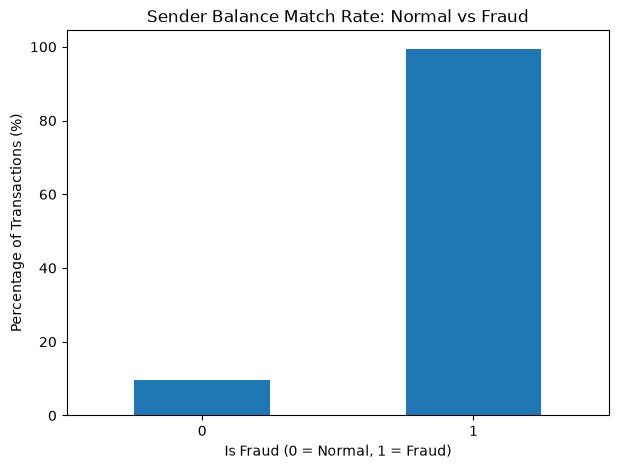

In [ ]:
# Calculate percentage of sender balance matches for each class

sender_match_plot = (
    fraud_related_df
    .groupby("isFraud")["sender_balance_matches"]
    .mean()
    * 100
)

print(sender_match_plot)

plt.figure(figsize=(7, 5))

sender_match_plot.plot(kind="bar")

plt.title("Sender Balance Match Rate: Normal vs Fraud")
plt.xlabel("Is Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Percentage of Transactions (%)")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# Create balance consistency features

df = df.copy()

# Difference between expected and actual sender balance
df["sender_balance_error"] = abs(
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

# Difference between expected and actual receiver balance
df["receiver_balance_error"] = abs(
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

print("New features created successfully.")

print("\nSender balance error:")
print(
    df.groupby("isFraud")["sender_balance_error"]
    .describe()
)

print("\nReceiver balance error:")
print(
    df.groupby("isFraud")["receiver_balance_error"]
    .describe()
)

New features created successfully.

Sender balance error:
             count           mean            std  min       25%       50%  \
isFraud                                                                     
0        6354407.0  201338.558304  606928.890761  0.0  3034.305  69049.31   
1           8213.0   10692.325265  265146.131130  0.0     0.000      0.00   

               75%          max  
isFraud                          
0        249953.43  92445516.64  
1             0.00  10000000.00  

Receiver balance error:
             count           mean           std  min  25%      50%        75%  \
isFraud                                                                         
0        6354407.0   92756.964361  4.295180e+05  0.0  0.0  5123.10   43227.16   
1           8213.0  745138.585637  1.862745e+06  0.0  0.0  9511.69  452294.74   

                 max  
isFraud               
0        75885725.63  
1        10000000.00  


In [ ]:
# Feature 1: Did the sender account become empty?

df["origin_empty_after"] = (
    df["newbalanceOrig"] == 0
).astype(int)


# Feature 2: Was the destination account empty before the transaction?

df["destination_empty_before"] = (
    df["oldbalanceDest"] == 0
).astype(int)


# Feature 3: Transaction amount relative to sender's initial balance

df["amount_to_origin_balance"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    0
)


# Check fraud rates for the binary features

print("Fraud rate by origin_empty_after:")
print(
    pd.crosstab(
        df["origin_empty_after"],
        df["isFraud"],
        normalize="columns"
    ) * 100
)


print("\nFraud rate by destination_empty_before:")
print(
    pd.crosstab(
        df["destination_empty_before"],
        df["isFraud"],
        normalize="columns"
    ) * 100
)


print("\nAmount-to-origin-balance statistics:")
print(
    df.groupby("isFraud")["amount_to_origin_balance"]
    .describe()
)

Fraud rate by origin_empty_after:
isFraud                     0          1
origin_empty_after                      
0                   43.322595   1.948131
1                   56.677405  98.051869

Fraud rate by destination_empty_before:
isFraud                           0          1
destination_empty_before                      
0                         57.524959  34.847193
1                         42.475041  65.152807

Amount-to-origin-balance statistics:
             count       mean          std  min  25%       50%       75%  \
isFraud                                                                    
0        6354407.0  81.817792  3397.897923  0.0  0.0  0.076139  2.228795   
1           8213.0   0.993779     0.390756  0.0  1.0  1.000000  1.000000   

                  max  
isFraud                
0        3.925476e+06  
1        2.952662e+01  


In [ ]:
# Define the features for our initial ML model

feature_columns = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "sender_balance_error",
    "receiver_balance_error",
    "origin_empty_after",
    "destination_empty_before",
    "amount_to_origin_balance"
]

# Input features
X = df[feature_columns].copy()

# Target
y = df["isFraud"].copy()

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nFraud distribution:")
print(y.value_counts())

print("\nFraud percentage:")
print((y.value_counts(normalize=True) * 100).round(4))

Feature dataset shape: (6362620, 12)
Target shape: (6362620,)

Features:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'sender_balance_error', 'receiver_balance_error', 'origin_empty_after', 'destination_empty_before', 'amount_to_origin_balance']

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# First split:
# 70% training
# 30% temporary data for validation + test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split the remaining 30% equally:
# 15% validation
# 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (4453834, 12)
Validation set: (954393, 12)
Test set: (954393, 12)


In [ ]:
def show_fraud_distribution(name, target):
    print(f"\n{name}")
    print(target.value_counts())
    
    print("\nPercentage:")
    print((target.value_counts(normalize=True) * 100).round(4))


show_fraud_distribution("TRAINING SET", y_train)
show_fraud_distribution("VALIDATION SET", y_val)
show_fraud_distribution("TEST SET", y_test)


TRAINING SET
isFraud
0    4448085
1       5749
Name: count, dtype: int64

Percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

VALIDATION SET
isFraud
0    953161
1      1232
Name: count, dtype: int64

Percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

TEST SET
isFraud
0    953161
1      1232
Name: count, dtype: int64

Percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


In [ ]:
import sys
from pathlib import Path

# Add the project root to Python's path
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import create_preprocessor

print("Preprocessor imported successfully!")

Preprocessor imported successfully!


In [ ]:
# Create the preprocessing pipeline
preprocessor = create_preprocessor()

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Validation data shape:", X_val_processed.shape)
print("Test data shape:", X_test_processed.shape)

Training data shape: (4453834, 16)
Validation data shape: (954393, 16)
Test data shape: (954393, 16)


In [ ]:
# Get the names of all features after preprocessing

feature_names = preprocessor.get_feature_names_out()

print("Processed feature names:\n")

for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Processed feature names:

1. numerical__step
2. numerical__amount
3. numerical__oldbalanceOrg
4. numerical__newbalanceOrig
5. numerical__oldbalanceDest
6. numerical__newbalanceDest
7. numerical__sender_balance_error
8. numerical__receiver_balance_error
9. numerical__amount_to_origin_balance
10. binary__origin_empty_after
11. binary__destination_empty_before
12. categorical__type_CASH_IN
13. categorical__type_CASH_OUT
14. categorical__type_DEBIT
15. categorical__type_PAYMENT
16. categorical__type_TRANSFER


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create a baseline model
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

# Train on the processed training data
dummy_model.fit(X_train_processed, y_train)

# Predict validation data
dummy_predictions = dummy_model.predict(X_val_processed)

# Evaluate
print("Accuracy:", round(
    accuracy_score(y_val, dummy_predictions), 4
))

print("Precision:", round(
    precision_score(y_val, dummy_predictions, zero_division=0), 4
))

print("Recall:", round(
    recall_score(y_val, dummy_predictions, zero_division=0), 4
))

print("F1 Score:", round(
    f1_score(y_val, dummy_predictions, zero_division=0), 4
))

print("\nClassification Report:")
print(classification_report(
    y_val,
    dummy_predictions,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_val,
    dummy_predictions
))

Accuracy: 0.9987
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.00      0.00      0.00      1232

    accuracy                           1.00    954393
   macro avg       0.50      0.50      0.50    954393
weighted avg       1.00      1.00      1.00    954393


Confusion Matrix:
[[953161      0]
 [  1232      0]]


## training

regration

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Create Logistic Regression model

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [ ]:
# Predicted class using the default threshold of 0.5
val_predictions = logistic_model.predict(
    X_val_processed
)

# Probability that each transaction is fraud
val_probabilities = logistic_model.predict_proba(
    X_val_processed
)[:, 1]

print("Predictions and probabilities generated successfully!")

Predictions and probabilities generated successfully!


In [ ]:
accuracy = accuracy_score(y_val, val_predictions)
precision = precision_score(y_val, val_predictions, zero_division=0)
recall = recall_score(y_val, val_predictions, zero_division=0)
f1 = f1_score(y_val, val_predictions, zero_division=0)

roc_auc = roc_auc_score(y_val, val_probabilities)
pr_auc = average_precision_score(y_val, val_probabilities)

print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 45)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        val_predictions,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        val_predictions
    )
)

LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy:  0.9721
Precision: 0.0433
Recall:    0.9797
F1 Score:  0.0830
ROC-AUC:   0.9963
PR-AUC:    0.6042

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    953161
           1       0.04      0.98      0.08      1232

    accuracy                           0.97    954393
   macro avg       0.52      0.98      0.53    954393
weighted avg       1.00      0.97      0.98    954393


Confusion Matrix:
[[926519  26642]
 [    25   1207]]


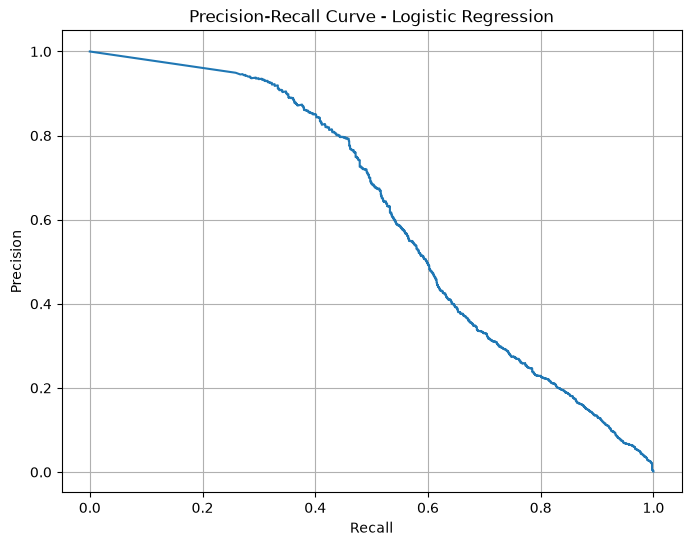

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(
    y_val,
    val_probabilities
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    recalls,
    precisions
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.grid()

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds_to_test = [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9
]

results = []

for threshold in thresholds_to_test:

    # Convert probabilities into fraud / normal predictions
    threshold_predictions = (
        val_probabilities >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        threshold_predictions
    ).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            threshold_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            threshold_predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_val,
            threshold_predictions,
            zero_division=0
        ),
        "fraud_caught": tp,
        "fraud_missed": fn,
        "false_alarms": fp
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1_score,fraud_caught,fraud_missed,false_alarms
0,0.1,0.010497,0.997565,0.020776,1229,3,115850
1,0.2,0.015287,0.997565,0.030113,1229,3,79164
2,0.3,0.021791,0.996753,0.042649,1228,4,55126
3,0.4,0.031184,0.988636,0.060460,1218,14,37841
4,0.5,0.043341,0.979708,0.083010,1207,25,26642
5,0.6,0.056878,0.967532,0.107441,1192,40,19765
6,0.7,0.075230,0.943182,0.139345,1162,70,14284
7,0.8,0.106025,0.921266,0.190165,1135,97,9570
8,0.9,0.159091,0.875000,0.269231,1078,154,5698


In [ ]:
# Example business costs

FALSE_POSITIVE_COST = 10
FALSE_NEGATIVE_COST = 1000


# Create a copy so we keep the original table
business_results = threshold_results.copy()


# Calculate investigation cost from false alarms
business_results["false_alarm_cost"] = (
    business_results["false_alarms"]
    * FALSE_POSITIVE_COST
)


# Calculate cost of missed fraud
business_results["missed_fraud_cost"] = (
    business_results["fraud_missed"]
    * FALSE_NEGATIVE_COST
)


# Total business cost
business_results["total_business_cost"] = (
    business_results["false_alarm_cost"]
    + business_results["missed_fraud_cost"]
)


# Display useful columns
business_results[
    [
        "threshold",
        "fraud_caught",
        "fraud_missed",
        "false_alarms",
        "precision",
        "recall",
        "f1_score",
        "total_business_cost"
    ]
]

,threshold,fraud_caught,fraud_missed,false_alarms,precision,recall,f1_score,total_business_cost
0,0.1,1229,3,115850,0.010497,0.997565,0.020776,1161500
1,0.2,1229,3,79164,0.015287,0.997565,0.030113,794640
2,0.3,1228,4,55126,0.021791,0.996753,0.042649,555260
3,0.4,1218,14,37841,0.031184,0.988636,0.060460,392410
4,0.5,1207,25,26642,0.043341,0.979708,0.083010,291420
5,0.6,1192,40,19765,0.056878,0.967532,0.107441,237650
6,0.7,1162,70,14284,0.075230,0.943182,0.139345,212840
7,0.8,1135,97,9570,0.106025,0.921266,0.190165,192700
8,0.9,1078,154,5698,0.159091,0.875000,0.269231,210980


## random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
import time

start_time = time.time()

# Train Random Forest
random_forest_model.fit(
    X_train_processed,
    y_train
)

training_time = time.time() - start_time

print("Random Forest training completed!")
print(f"Training time: {training_time:.2f} seconds")

Random Forest training completed!
Training time: 207.42 seconds


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Predict classes
rf_val_predictions = random_forest_model.predict(
    X_val_processed
)

# Predict fraud probabilities
rf_val_probabilities = random_forest_model.predict_proba(
    X_val_processed
)[:, 1]


# Calculate metrics
rf_accuracy = accuracy_score(y_val, rf_val_predictions)

rf_precision = precision_score(
    y_val,
    rf_val_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_val,
    rf_val_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_val,
    rf_val_predictions,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_val,
    rf_val_probabilities
)

rf_pr_auc = average_precision_score(
    y_val,
    rf_val_probabilities
)


# Print results
print("RANDOM FOREST - VALIDATION RESULTS")
print("=" * 45)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        rf_val_predictions,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        rf_val_predictions
    )
)

RANDOM FOREST - VALIDATION RESULTS
Accuracy:  1.0000
Precision: 1.0000
Recall:    0.9968
F1 Score:  0.9984
ROC-AUC:   0.9984
PR-AUC:    0.9968

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393


Confusion Matrix:
[[953161      0]
 [     4   1228]]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get processed feature names
feature_names = preprocessor.get_feature_names_out()

# Get Random Forest feature importance
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": random_forest_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                                feature  importance
6       numerical__sender_balance_error    0.402422
9            binary__origin_empty_after    0.123000
2              numerical__oldbalanceOrg    0.116226
3             numerical__newbalanceOrig    0.089695
1                     numerical__amount    0.071156
14            categorical__type_PAYMENT    0.055968
8   numerical__amount_to_origin_balance    0.036299
15           categorical__type_TRANSFER    0.026775
0                       numerical__step    0.023734
7     numerical__receiver_balance_error    0.014568
5             numerical__newbalanceDest    0.011503
11            categorical__type_CASH_IN    0.011290
12           categorical__type_CASH_OUT    0.009895
4             numerical__oldbalanceDest    0.005600
10     binary__destination_empty_before    0.001689
13              categorical__type_DEBIT    0.000181


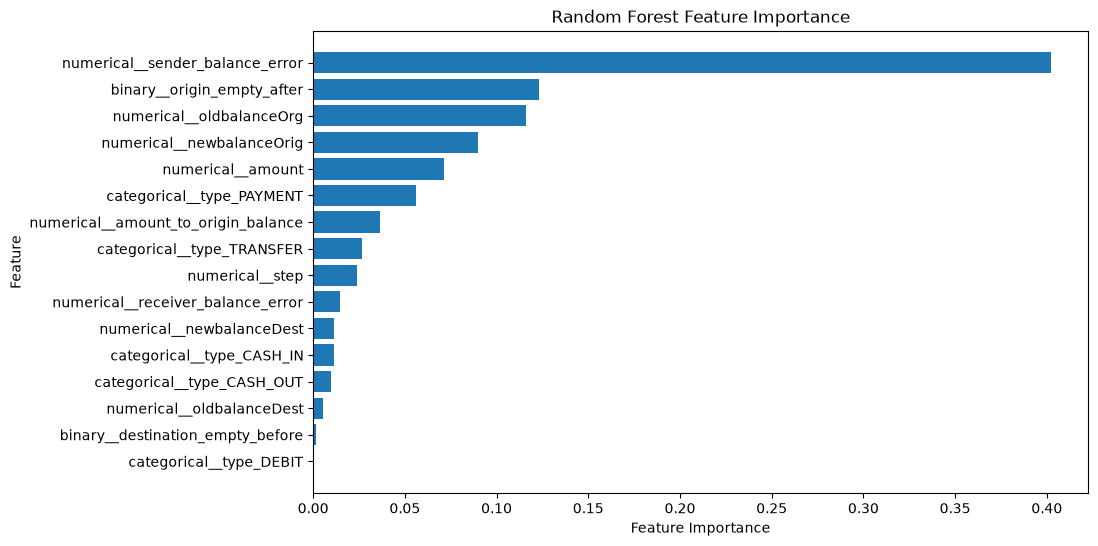

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import pandas as pd

# Random Forest predictions on validation data
rf_val_pred = random_forest_model.predict(X_val_processed)

# Create a dataframe for analysis
validation_results = X_val.copy()

validation_results["actual"] = y_val.values
validation_results["prediction"] = rf_val_pred

# Find fraud transactions that the model missed
missed_frauds = validation_results[
    (validation_results["actual"] == 1) &
    (validation_results["prediction"] == 0)
]

print("Number of missed fraud transactions:", len(missed_frauds))

missed_frauds.head()

Number of missed fraud transactions: 4


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,sender_balance_error,receiver_balance_error,origin_empty_after,destination_empty_before,amount_to_origin_balance,actual,prediction
77745,10,CASH_OUT,277970.88,0.00,0.0,0.00,277970.88,277970.88,0.00,1,1,0.000000,1,0
217978,13,TRANSFER,123194.95,79466.45,0.0,535933.16,263908.84,43728.50,395219.27,1,0,1.550276,1,0
25875,8,TRANSFER,1078013.76,0.00,0.0,0.00,970749.68,1078013.76,107264.08,1,1,0.000000,1,0
2622102,208,CASH_OUT,291519.84,0.00,0.0,0.00,291519.84,291519.84,0.00,1,1,0.000000,1,0


In [ ]:
# Correctly detected fraud transactions
detected_frauds = validation_results[
    (validation_results["actual"] == 1) &
    (validation_results["prediction"] == 1)
]

# Features we want to compare
important_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "sender_balance_error",
    "receiver_balance_error",
    "origin_empty_after",
    "destination_empty_before",
    "amount_to_origin_balance"
]

# Compare average values
comparison = pd.DataFrame({
    "Correctly Detected Fraud": detected_frauds[important_features].mean(),
    "Missed Fraud": missed_frauds[important_features].mean()
})

comparison

,Correctly Detected Fraud,Missed Fraud
amount,1.449009e+06,442674.857500
oldbalanceOrg,1.594230e+06,19866.612500
newbalanceOrig,1.452211e+05,0.000000
sender_balance_error,1.241890e-11,422808.245000
receiver_balance_error,6.751764e+05,125620.837500
origin_empty_after,9.845277e-01,1.000000
destination_empty_before,6.636808e-01,0.750000
amount_to_origin_balance,9.918160e-01,0.387569


## XGBoost

In [ ]:
try:
    import xgboost
    print("XGBoost version:", xgboost.__version__)
    print("XGBoost is ready!")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is not installed.


In [ ]:
import xgboost

print("XGBoost version:", xgboost.__version__)
print("XGBoost is ready!")

XGBoost version: 3.4.1
XGBoost is ready!


In [ ]:
from xgboost import XGBClassifier
import time

# Start timer
start_time = time.time()

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    
    objective="binary:logistic",
    eval_metric="logloss",
    
    tree_method="hist",
    n_jobs=-1,
    
    random_state=42
)

# Train the model
xgb_model.fit(
    X_train_processed,
    y_train
)

# Training time
training_time = time.time() - start_time

print(f"XGBoost training completed in {training_time:.2f} seconds")

XGBoost training completed in 46.54 seconds


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Fraud probabilities
xgb_val_proba = xgb_model.predict_proba(X_val_processed)[:, 1]

# Default threshold = 0.5
xgb_val_pred = (xgb_val_proba >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_val, xgb_val_pred)
precision = precision_score(y_val, xgb_val_pred, zero_division=0)
recall = recall_score(y_val, xgb_val_pred, zero_division=0)
f1 = f1_score(y_val, xgb_val_pred, zero_division=0)

roc_auc = roc_auc_score(y_val, xgb_val_proba)
pr_auc = average_precision_score(y_val, xgb_val_proba)

# Print results
print("XGBOOST - VALIDATION RESULTS")
print("=" * 45)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, xgb_val_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, xgb_val_pred))

XGBOOST - VALIDATION RESULTS
Accuracy:  1.0000
Precision: 0.9976
Recall:    0.9968
F1 Score:  0.9972
ROC-AUC:   0.9999
PR-AUC:    0.9981

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393


Confusion Matrix:
[[953158      3]
 [     4   1228]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Thresholds to test
thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:
    
    predictions = (xgb_val_proba >= threshold).astype(int)
    
    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )
    
    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )
    
    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )
    
    # Confusion matrix values
    cm = confusion_matrix(y_val, predictions)
    
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        "threshold": threshold,
        "fraud_caught": tp,
        "fraud_missed": fn,
        "false_alarms": fp,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

xgb_threshold_results = pd.DataFrame(results)

xgb_threshold_results

,threshold,fraud_caught,fraud_missed,false_alarms,precision,recall,f1_score
0,0.1,1228,4,6,0.995138,0.996753,0.995945
1,0.2,1228,4,5,0.995945,0.996753,0.996349
2,0.3,1228,4,5,0.995945,0.996753,0.996349
3,0.4,1228,4,4,0.996753,0.996753,0.996753
4,0.5,1228,4,3,0.997563,0.996753,0.997158
5,0.6,1228,4,3,0.997563,0.996753,0.997158
6,0.7,1228,4,3,0.997563,0.996753,0.997158
7,0.8,1228,4,3,0.997563,0.996753,0.997158
8,0.9,1228,4,3,0.997563,0.996753,0.997158


In [ ]:
# Test more detailed thresholds
fine_thresholds = [
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.1,
    0.2,
    0.5,
    0.9
]

fine_results = []

for threshold in fine_thresholds:

    predictions = (xgb_val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    fine_results.append({
        "threshold": threshold,
        "fraud_caught": tp,
        "fraud_missed": fn,
        "false_alarms": fp,
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

xgb_fine_threshold_results = pd.DataFrame(fine_results)

xgb_fine_threshold_results

,threshold,fraud_caught,fraud_missed,false_alarms,precision,recall,f1_score
0,0.001,1228,4,268,0.820856,0.996753,0.900293
1,0.005,1228,4,58,0.954899,0.996753,0.975377
2,0.010,1228,4,31,0.975377,0.996753,0.985949
3,0.020,1228,4,22,0.982400,0.996753,0.989525
4,0.050,1228,4,9,0.992724,0.996753,0.994735
5,0.100,1228,4,6,0.995138,0.996753,0.995945
6,0.200,1228,4,5,0.995945,0.996753,0.996349
7,0.500,1228,4,3,0.997563,0.996753,0.997158
8,0.900,1228,4,3,0.997563,0.996753,0.997158


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd


# ==========================================
# RANDOM FOREST - TEST EVALUATION
# ==========================================

rf_test_pred = random_forest_model.predict(X_test_processed)
rf_test_proba = random_forest_model.predict_proba(X_test_processed)[:, 1]

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_test_pred),
    "Precision": precision_score(y_test, rf_test_pred),
    "Recall": recall_score(y_test, rf_test_pred),
    "F1 Score": f1_score(y_test, rf_test_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_test_proba),
    "PR-AUC": average_precision_score(y_test, rf_test_proba)
}


# ==========================================
# XGBOOST - TEST EVALUATION
# ==========================================

xgb_test_pred = xgb_model.predict(X_test_processed)
xgb_test_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_test_pred),
    "Precision": precision_score(y_test, xgb_test_pred),
    "Recall": recall_score(y_test, xgb_test_pred),
    "F1 Score": f1_score(y_test, xgb_test_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_test_proba),
    "PR-AUC": average_precision_score(y_test, xgb_test_proba)
}


# ==========================================
# FINAL COMPARISON
# ==========================================

final_comparison = pd.DataFrame([
    rf_results,
    xgb_results
])

print("FINAL TEST SET MODEL COMPARISON")
print("=" * 70)

display(final_comparison.round(6))

FINAL TEST SET MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest,0.999995,1.0,0.995942,0.997967,0.998375,0.996603
1,XGBoost,0.999995,1.0,0.995942,0.997967,0.999908,0.997239


In [ ]:
import os
import joblib

# Create models directory if needed
os.makedirs("../models", exist_ok=True)

# Save trained XGBoost model
joblib.dump(
    xgb_model,
    "../models/xgboost_fraud_model.joblib"
)

# Save fitted preprocessor
joblib.dump(
    preprocessor,
    "../models/preprocessor.joblib"
)

print("XGBoost model saved successfully!")
print("Preprocessor saved successfully!")

XGBoost model saved successfully!
Preprocessor saved successfully!


In [ ]:
import numpy as np
import pandas as pd

# Get fraud probabilities from Random Forest
rf_val_prob = random_forest_model.predict_proba(X_val_processed)[:, 1]

print("Minimum probability:", rf_val_prob.min())
print("Maximum probability:", rf_val_prob.max())

# Check probabilities excluding exact 0 and 1
middle_probs = rf_val_prob[
    (rf_val_prob > 0) & (rf_val_prob < 1)
]

print("\nNumber of probabilities between 0 and 1:", len(middle_probs))

print("\nSample intermediate probabilities:")
print(np.sort(middle_probs)[:20])

print("\nProbability percentiles:")
print(pd.Series(rf_val_prob).describe(
    percentiles=[0.001, 0.01, 0.05, 0.1, 0.5, 0.9, 0.99, 0.999]
))

NameError: name 'random_forest_model' is not defined